# 05 · C3S Atlas: scenarios, warming levels, and model spread

**Time:** 45 minutes · **Audience:** undergraduate / introductory graduate GIS and Earth science.

**By the end:** Use real C3S Atlas auxiliary data, preserve missing categories, and compare global warming levels with regional change.

[Run in JupyterLite](https://jltobias.github.io/JupyterLite-zarr-sql-views/lite/lab/index.html?path=05_c3s_atlas.ipynb) · [Earth lab](https://jltobias.github.io/JupyterLite-zarr-sql-views/lab/) · [Sources and licenses](https://jltobias.github.io/JupyterLite-zarr-sql-views/book/credits.html)

Run cells from top to bottom with **Shift+Enter**. The first kernel start downloads Python WebAssembly packages.
The bundled exercises need no data-service account. Save a copy with **File → Save and Export Notebook As** before clearing browser storage.

![Four-stage workflow: STAC discovery, Zarr reading, SQL selection, linked views](assets/pipeline.svg)

In [1]:
from course import *
import numpy as np
import matplotlib.pyplot as plt
print('Ready: Python + NumPy + local teaching data')

Ready: Python + NumPy + local teaching data


## 1. Start in the official Atlas

Open the [Copernicus C3S Atlas](https://atlas.climate.copernicus.eu/). Select an African region, a temperature variable,
CMIP6, a scenario, a baseline, and a future period. Record these choices before comparing maps.
The original request’s “C32” is interpreted here as **C3S**.

The bundled CSV is the actual CMIP6 global-warming-level table from the official C3S Atlas user-tools repository,
pinned at `8d80d4e98053d96077ba67f29464b4f373ff4037`. It lists model-member averaging periods,
not local African temperature values. A global warming level and a local anomaly are different quantities.

In [2]:
rows = list(csv.reader(Path('data/CMIP6_WarmingLevels.csv').open(encoding='utf-8')))
levels, scenarios = rows[0][1:], rows[1][1:]
print('Columns:', list(zip(levels, scenarios)))
print('Model-member rows:', len(rows)-2)

Columns: [('1.5', 'ssp119'), ('2', 'ssp119'), ('3', 'ssp119'), ('4', 'ssp119'), ('1.5', 'ssp126'), ('2', 'ssp126'), ('3', 'ssp126'), ('4', 'ssp126'), ('1.5', 'ssp245'), ('2', 'ssp245'), ('3', 'ssp245'), ('4', 'ssp245'), ('1.5', 'ssp370'), ('2', 'ssp370'), ('3', 'ssp370'), ('4', 'ssp370'), ('1.5', 'ssp585'), ('2', 'ssp585'), ('3', 'ssp585'), ('4', 'ssp585')]
Model-member rows: 30


## 2. Parse periods and preserve sentinels

The upstream selection code uses entries that contain a year range. Here `9999`, `NA`, blanks, and other text remain explicit categories.
We do **not** turn either sentinel into a year, zero warming, or a probability. Their precise semantics should be checked against the chosen dataset version.

In [3]:
import re
from collections import Counter
def periods_for(level='2', scenario='ssp245'):
    j = next(i for i,pair in enumerate(zip(levels, scenarios)) if pair == (level, scenario)) + 1
    periods=[]; excluded=Counter()
    for row in rows[2:]:
        value=row[j]
        if re.fullmatch(r'\d{4}-\d{4}', value):
            start,end=map(int,value.split('-')); periods.append((row[0],start,end))
        else: excluded[value]+=1
    return periods, excluded
periods, excluded = periods_for()
print('Valid windows:',len(periods),'Excluded codes:',dict(excluded))
print(periods[:4])

Valid windows: 22 Excluded codes: {'9999': 8}
[('CCCR-IITM_IITM-ESM_r1i1p1f1', 2052, 2071), ('CMCC_CMCC-CM2-SR5_r1i1p1f1', 2029, 2048), ('CMCC_CMCC-ESM2_r1i1p1f1', 2031, 2050), ('CNRM-CERFACS_CNRM-CM6-1-HR_r1i1p1f2', 2024, 2043)]


## 3. Visualise model-member spread

The midpoint labels the supplied averaging window. It is not a prediction of a particular year’s temperature.
These model-member entries are not independent draws from a probability distribution; models may share structure.

ssp126 excluded: {'9999': 9, 'NA': 12}
ssp245 excluded: {'9999': 8}
ssp370 excluded: {'9999': 9}
ssp585 excluded: {'9999': 4}


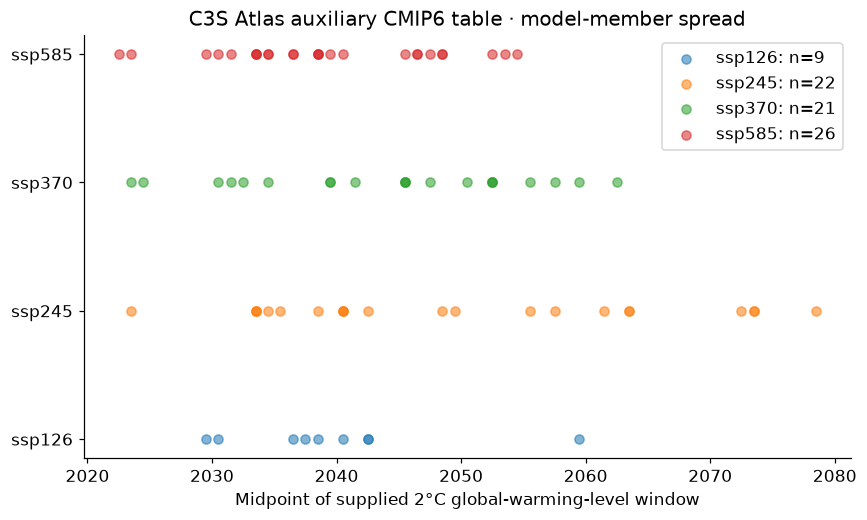

In [4]:
fig,ax=plt.subplots(figsize=(9,5))
for k,scenario in enumerate(['ssp126','ssp245','ssp370','ssp585']):
    p, missing=periods_for('2',scenario)
    mids=[(start+end)/2 for _,start,end in p]
    ax.scatter(mids, np.full(len(mids),k), alpha=.55, label=f'{scenario}: n={len(mids)}')
    print(scenario,'excluded:',dict(missing))
ax.set_yticks(range(4),['ssp126','ssp245','ssp370','ssp585'])
ax.set(xlabel='Midpoint of supplied 2°C global-warming-level window',title='C3S Atlas auxiliary CMIP6 table · model-member spread')
ax.legend(loc='best'); plt.show()

## 4. Bridge to regional climate evidence

In the Atlas compare the same African region at 1.5°C and 2°C global warming. Record regional change and ensemble spread,
the variable’s units, the baseline, and the Atlas export citation. Repeat for a second African region and one region outside Africa.
Do not reuse the synthetic temperature cube as Atlas data.

For gridded downloads, use the [C3S Atlas dataset](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas).
CDS requests can require an account and accepted terms. Prepare an approved regional subset outside JupyterLite;
retain the selected product’s license and acknowledgement. The [official user-tools book](https://ecmwf-projects.github.io/c3s-atlas/intro.html)
provides the full xarray/CDS workflow. This course does not embed credentials or redistribute arbitrary CDS data.

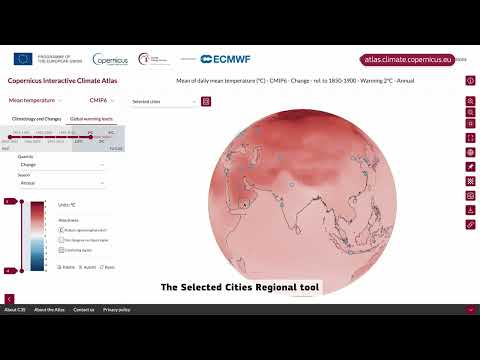

In [5]:
display(YouTubeVideo('o62IPhpvsAI', width=720, height=405))

Video: **Climate Atlas – Tutorial video**, Copernicus ECMWF. Hosted by the creator on YouTube; may require network access and captions are controlled by the provider.
[Open video directly](https://www.youtube.com/watch?v=o62IPhpvsAI). Reading alternative: [official Atlas guide](https://climate.copernicus.eu/copernicus-interactive-climate-atlas-guide-powerful-new-c3s-tool).

## Try it yourself

Change the warming level to 3°C. Report valid windows and excluded categories for each scenario. Explain why a histogram is not a calibrated likelihood.

## Check your reasoning

Availability changes the ensemble. Always report the included sample size; global warming levels do not directly specify local impacts.

## Evidence journal

Write four sentences: **what I observed; how I calculated it; what this cannot establish; what evidence I need next**.
For any figure you reuse, retain its units, date or scenario, data origin, transformations, and attribution.

## Sources and credit

- [C3S Atlas user tools](https://github.com/ecmwf-projects/c3s-atlas), European Union, Apache 2.0; pinned auxiliary CMIP6 warming-level table.
- [C3S Atlas dataset, DOI 10.24381/cds.h35hb680](https://doi.org/10.24381/cds.h35hb680)
- [IPCC AR6 WGII, Chapter 9: Africa](https://www.ipcc.ch/report/ar6/wg2/chapter/chapter-9/). Linked context, not redistributed data.

Teaching adaptation of [dzole0311/zarr-sql-views](https://github.com/dzole0311/zarr-sql-views), ISC.
Original teaching code and prose: JupyterLite-zarr-sql-views contributors, ISC. Data keep their separate licenses.